In [2]:
import pandas as pd
# Read the CSV file into a DataFrame
df = pd.read_csv('/Users/bina/Movies/sales_dashboard_project/data/sales_dashboard_dataset.csv')
# Convert the 'Order_Date' column to datetime format
df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%Y-%m-%d')

df

,Order_ID,Order_Date,Customer_Name,Region,Product,Category,Quantity,Unit_Price,Revenue,Cost,Profit
0,1001,2025-01-07,Michael,South,Monitor,Electronics,2,250,500,360,140
1,1002,2025-01-27,Sarah,West,Phone,Electronics,3,800,2400,1800,600
2,1003,2025-01-24,Emma,South,Laptop,Electronics,1,1200,1200,900,300
3,1004,2025-01-07,Emma,West,Desk,Furniture,10,300,3000,2200,800
4,1005,2025-05-31,Michael,North,Phone,Electronics,8,800,6400,4800,1600
...,...,...,...,...,...,...,...,...,...,...,...
95,1096,2025-03-27,Sarah,South,Desk,Furniture,10,300,3000,2200,800
96,1097,2025-02-27,Emma,South,Monitor,Electronics,5,250,1250,900,350
97,1098,2025-03-04,Olivia,North,Laptop,Electronics,1,1200,1200,900,300
98,1099,2025-06-11,Emma,West,Chair,Furniture,7,150,1050,700,350


In [3]:
total_revenue = df['Revenue'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order_ID'].nunique()

profit_margine = (total_profit / total_revenue) * 100

print(f'Total Revenue: ${total_revenue:,.2f}')
print(f'Total Profit: ${total_profit:,.2f}')
print(f'Total Orders: {total_orders}')
print(f'Profit Margin: {profit_margine:.2f}%')

Total Revenue: $299,250.00
Total Profit: $78,860.00
Total Orders: 100
Profit Margin: 26.35%


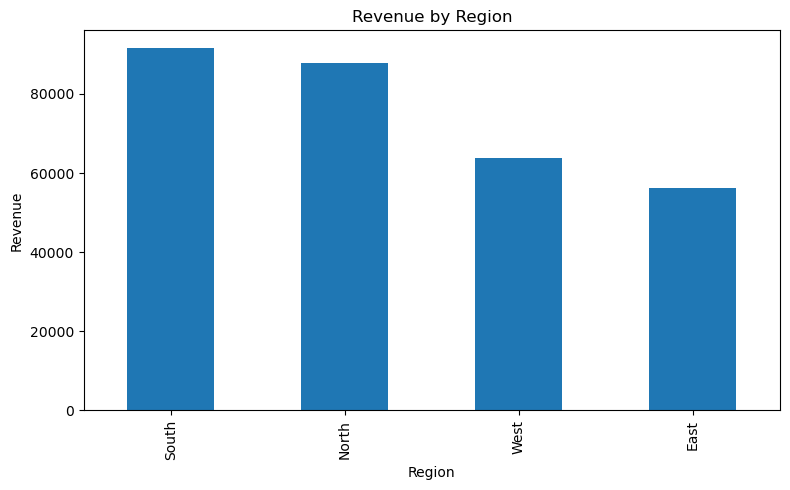

In [4]:
import matplotlib.pyplot as plt

region_sales = (
    df.groupby('Region')['Revenue']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')

plt.title('Revenue by Region')
plt.ylabel('Revenue')
plt.xlabel('Region')

plt.tight_layout()
plt.show()

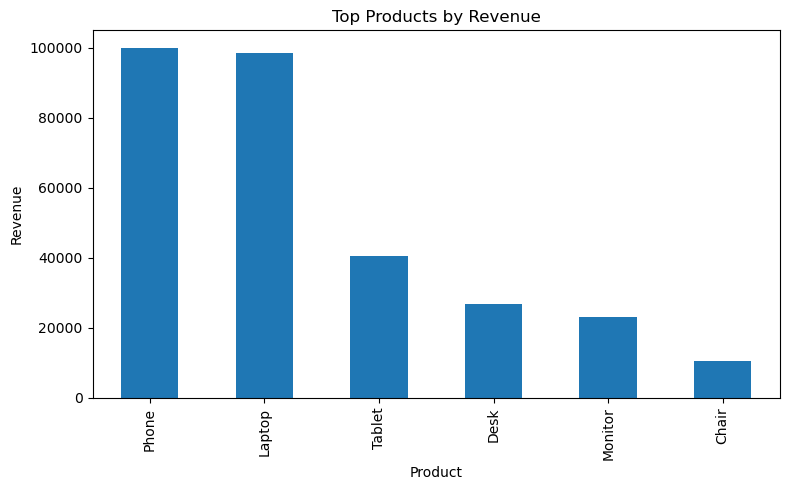

In [5]:
top_products = (
    df.groupby('Product')['Revenue']
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
top_products.plot(kind='bar')

plt.title('Top Products by Revenue')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

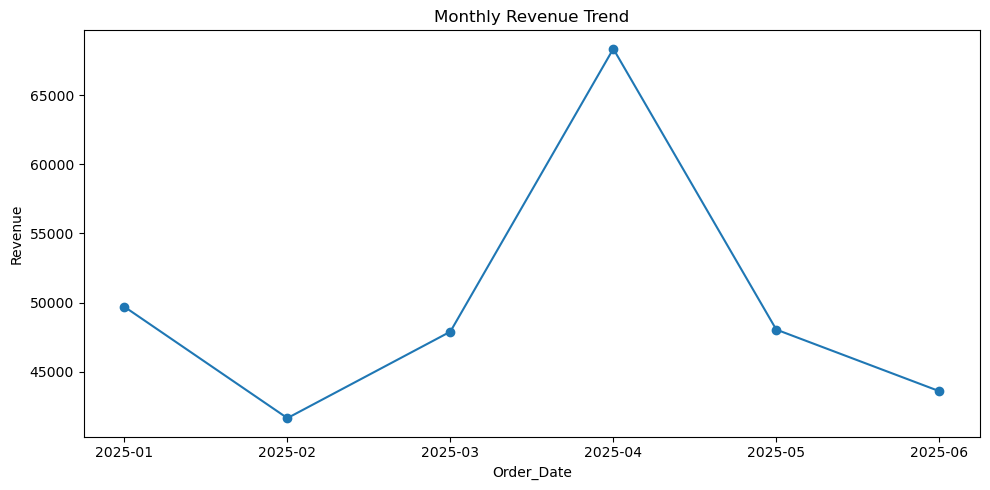

In [6]:
monthly_sales = (
    df.groupby(
        df['Order_Date'].dt.to_period('M')
    )['Revenue']
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')

plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()

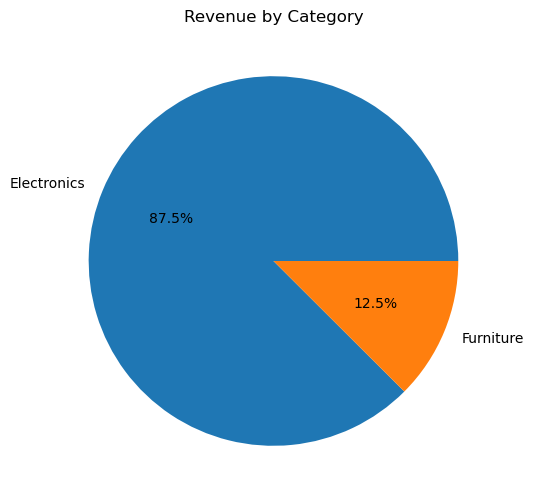

In [7]:
category_sales = (
    df.groupby('Category')['Revenue']
      .sum()
)

plt.figure(figsize=(6,6))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct='%1.1f%%'
)

plt.title('Revenue by Category')

plt.show()

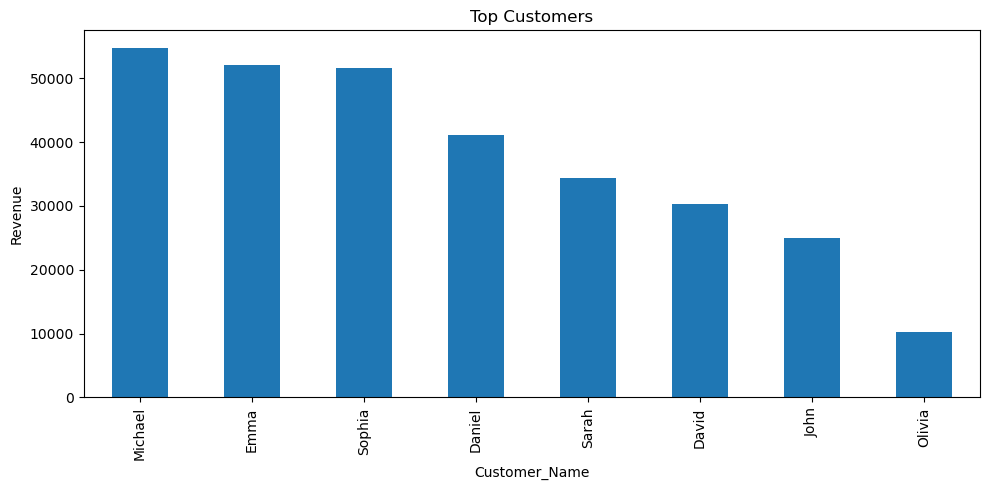

In [9]:
top_customers = (
    df.groupby('Customer_Name')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10,5))
top_customers.plot(kind='bar')

plt.title('Top Customers')
plt.ylabel('Revenue')

plt.tight_layout()
plt.show()